<a href="https://colab.research.google.com/github/nemo10-boop/WUEKM/blob/main/Classical_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing and importing

In [ ]:
!pip install -q torch torchvision scikit-image matplotlib seaborn

import os, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from scipy.ndimage import gaussian_filter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


config

In [ ]:
IMG_SIZE   = 28
BATCH_SIZE = 4
EPOCHS     = 100
LR         = 1e-3
NUM_WORKERS = 2

print(" Config ready")
print(f"   Image size : {IMG_SIZE}x{IMG_SIZE}")
print(f"   Batch size : {BATCH_SIZE}")
print(f"   Epochs     : {EPOCHS}")
print(f"   LR         : {LR}")

 Config ready
   Image size : 28x28
   Batch size : 4
   Epochs     : 100
   LR         : 0.001


Helper functions

In [ ]:
def filter_binary(dataset, class_a, class_b, max_per_class=None):
    targets = np.array(dataset.targets)
    idx_a   = np.where(targets == class_a)[0]
    idx_b   = np.where(targets == class_b)[0]

    if max_per_class:
        idx_a = idx_a[:max_per_class]
        idx_b = idx_b[:max_per_class]

    indices = np.concatenate([idx_a, idx_b])
    np.random.shuffle(indices)

    new_targets = targets.copy()
    new_targets[targets == class_a] = 0
    new_targets[targets == class_b] = 1
    dataset.targets = new_targets.tolist()

    return Subset(dataset, indices)


def split_dataset(dataset, train_n, val_n, test_n):
    total    = len(dataset)
    leftover = total - train_n - val_n - test_n
    train_ds, val_ds, test_ds, _ = random_split(
        dataset,
        [train_n, val_n, test_n, leftover],
        generator=torch.Generator().manual_seed(SEED)
    )
    return train_ds, val_ds, test_ds

print(" Helper functions ready")

 Helper functions ready


Loading MNIST dataset

In [ ]:
base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download
mnist_train_full = datasets.MNIST(root='./data', train=True,  download=True, transform=base_transform)
mnist_test_full  = datasets.MNIST(root='./data', train=False, download=True, transform=base_transform)

# Filter to digits 3 vs 5
mnist_train_bin = filter_binary(mnist_train_full, 3, 5, max_per_class=3125)
mnist_test_bin  = filter_binary(mnist_test_full,  3, 5, max_per_class=500)

# Split
mnist_train, mnist_val, _ = split_dataset(mnist_train_bin, 5000, 1250, 0)

# Loaders
mnist_loaders = {
    'train': DataLoader(mnist_train,    batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS),
    'val'  : DataLoader(mnist_val,      batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
    'test' : DataLoader(mnist_test_bin, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
}

print(" MNIST ready")
print(f"   Train : {len(mnist_train)}")
print(f"   Val   : {len(mnist_val)}")
print(f"   Test  : {len(mnist_test_bin)}")

 MNIST ready
   Train : 5000
   Val   : 1250
   Test  : 1000


Loading F-MNIST dataset

In [ ]:
fmnist_train_full = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=base_transform)
fmnist_test_full  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=base_transform)

# Class 0 = T-shirt, Class 1 = Trouser
fmnist_train_bin = filter_binary(fmnist_train_full, 0, 1, max_per_class=3125)
fmnist_test_bin  = filter_binary(fmnist_test_full,  0, 1, max_per_class=500)

fmnist_train, fmnist_val, _ = split_dataset(fmnist_train_bin, 5000, 1250, 0)

fmnist_loaders = {
    'train': DataLoader(fmnist_train,    batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS),
    'val'  : DataLoader(fmnist_val,      batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
    'test' : DataLoader(fmnist_test_bin, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
}

print(" Fashion-MNIST ready")
print(f"   Train : {len(fmnist_train)}")
print(f"   Val   : {len(fmnist_val)}")
print(f"   Test  : {len(fmnist_test_bin)}")

 Fashion-MNIST ready
   Train : 5000
   Val   : 1250
   Test  : 1000


Loading Brain Tumour MRI dataset

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:09<00:00, 16.7MB/s]



In [ ]:
!unzip brain-tumor-mri-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_279.jpg  
  inflating: Training/glioma/Tr-gl_28.jpg  
  inflating: Training/glioma/Tr-gl_280.jpg  
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg  
  infl

In [ ]:
!ls

brain_tumor_dataset	     brain_tumor_mri.zip  kaggle.json  Testing
brain-tumor-mri-dataset.zip  data		  sample_data  Training


In [ ]:
MRI_DIR = "/content"
MRI_ZIP = 'brain_tumor_mri.zip'

# Download
MRI_ZIP = "brain_tumor_mri.zip"

if not os.path.exists(MRI_ZIP):
    !kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset -f brain_tumor_dataset.zip -p .

    # Rename downloaded file
    !mv brain_tumor_dataset.zip brain_tumor_mri.zip

    print("Downloaded")
else:
    print("Already downloaded - skipping")

# Extract
if not os.path.exists(MRI_DIR):
    os.makedirs(MRI_DIR, exist_ok=True)
    !unzip -q brain_tumor_mri.zip -d {MRI_DIR}
    print("Extracted")
else:
    print("Already extracted - skipping")

# Show folder structure
for p in sorted(Path(MRI_DIR).rglob('*'))[:20]:
    print(p)

Already downloaded - skipping
Already extracted - skipping
/content/.config
/content/.config/.last_opt_in_prompt.yaml
/content/.config/.last_survey_prompt.yaml
/content/.config/.last_update_check.json
/content/.config/active_config
/content/.config/config_sentinel
/content/.config/configurations
/content/.config/configurations/config_default
/content/.config/default_configs.db
/content/.config/gce
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/logs
/content/.config/logs/2026.05.15
/content/.config/logs/2026.05.15/13.25.16.971279.log
/content/.config/logs/2026.05.15/13.25.35.059680.log
/content/.config/logs/2026.05.15/13.25.44.191228.log
/content/.config/logs/2026.05.15/13.25.45.794183.log
/content/.config/logs/2026.05.15/13.25.55.910698.log
/content/.config/logs/2026.05.15/13.25.56.641210.log
/content/Testing


In [ ]:
class MRIBinaryDataset(Dataset):
    BENIGN_FOLDERS    = {'notumor', 'no_tumor', 'no tumor'}
    MALIGNANT_FOLDERS = {'glioma', 'meningioma', 'pituitary'}

    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.samples   = []

        for img_path in Path(root_dir).rglob('*.jpg'):
            folder = img_path.parent.name.lower().replace('_', ' ').replace('-', ' ')
            if any(b in folder for b in self.BENIGN_FOLDERS):
                self.samples.append((str(img_path), 0))
            elif any(m in folder for m in self.MALIGNANT_FOLDERS):
                self.samples.append((str(img_path), 1))

        for img_path in Path(root_dir).rglob('*.png'):
            folder = img_path.parent.name.lower()
            if any(b in folder for b in self.BENIGN_FOLDERS):
                self.samples.append((str(img_path), 0))
            elif any(m in folder for m in self.MALIGNANT_FOLDERS):
                self.samples.append((str(img_path), 1))

        np.random.shuffle(self.samples)
        labels = [s[1] for s in self.samples]
        print(f"MRI total   : {len(self.samples)}")
        print(f"Benign (0)  : {labels.count(0)}")
        print(f"Malignant(1): {labels.count(1)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('L')
        if self.transform:
            img = self.transform(img)
        return img, label


mri_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mri_full = MRIBinaryDataset(MRI_DIR, transform=mri_transform)

mri_train, mri_val, mri_test = split_dataset(mri_full, 2089, 653, 523)

mri_loaders = {
    'train': DataLoader(mri_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS),
    'val'  : DataLoader(mri_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
    'test' : DataLoader(mri_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
}

print(f"Train : {len(mri_train)}")
print(f"Val   : {len(mri_val)}")
print(f"Test  : {len(mri_test)}")

MRI total   : 7200
Benign (0)  : 1800
Malignant(1): 5400
Train : 2089
Val   : 653
Test  : 523


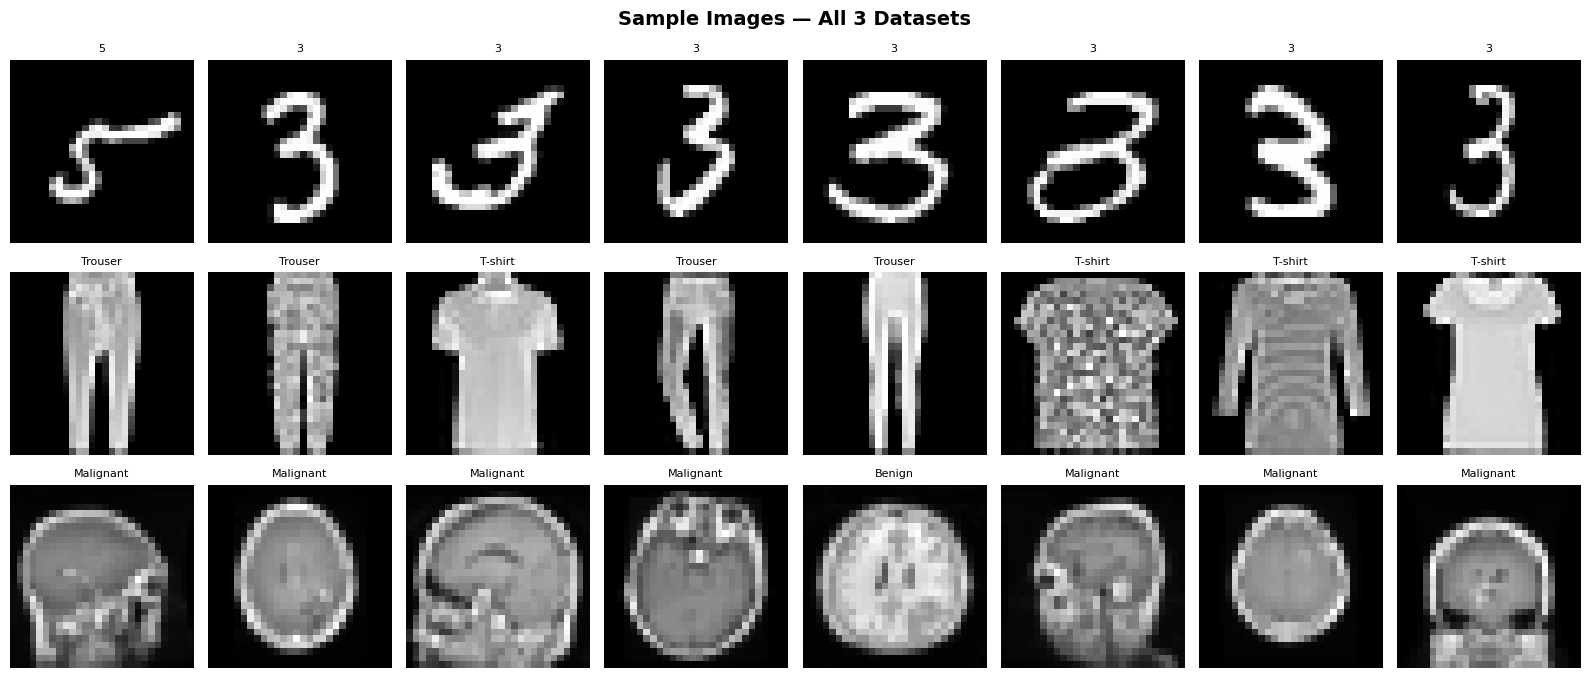

Saved dataset_samples.png


In [ ]:
fig, axes = plt.subplots(3, 8, figsize=(16, 7))
fig.suptitle('Sample Images — All 3 Datasets', fontsize=14, fontweight='bold')

dataset_info = [
    (mnist_train,  'MNIST 3 vs 5',              ['3', '5']),
    (fmnist_train, 'F-MNIST T-shirt vs Trouser', ['T-shirt', 'Trouser']),
    (mri_train,    'MRI Benign vs Malignant',    ['Benign', 'Malignant']),
]

for row, (ds, title, class_names) in enumerate(dataset_info):
    axes[row, 0].set_ylabel(title, fontsize=9)
    count = 0
    for img, label in ds:
        if count >= 8:
            break
        axes[row, count].imshow(img.squeeze().numpy(), cmap='gray')
        axes[row, count].set_title(class_names[label], fontsize=8)
        axes[row, count].axis('off')
        count += 1

plt.tight_layout()
plt.savefig('dataset_samples.png', dpi=120)
plt.show()
print("Saved dataset_samples.png")

In [ ]:
class ClassicalCNN(nn.Module):
    def __init__(self, in_channels=1, img_size=28):
        super().__init__()

        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                          # 28 → 14

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                          # 14 → 7
        )

        with torch.no_grad():
            dummy     = torch.zeros(1, in_channels, img_size, img_size)
            flat_size = self.conv_block(dummy).numel()

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.classifier(self.conv_block(x))


# Quick check
model_test   = ClassicalCNN().to(DEVICE)
total_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
dummy_out    = model_test(torch.randn(4, 1, 28, 28).to(DEVICE))

print(model_test)
print(f"\n Parameters : {total_params:,}")
print(f" Output shape: {tuple(dummy_out.shape)}")

ClassicalCNN(
  (conv_block): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=64, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

 Parameters : 105,377
 Output shape: (4, 1)


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE)
        labels = labels.float().unsqueeze(1).to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds       = (torch.sigmoid(outputs) >= 0.5).float()
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE)
        labels = labels.float().unsqueeze(1).to(DEVICE)

        outputs     = model(imgs)
        loss        = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        preds       = (torch.sigmoid(outputs) >= 0.5).float()
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total


def train_model(name, loaders):
    print(f"\n{'='*55}")
    print(f"  Training: {name}")
    print(f"{'='*55}")

    model     = ClassicalCNN().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=7, factor=0.5)

    history      = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_state   = None
    stagnant     = 0
    patience     = 15

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, loaders['train'], optimizer, criterion)
        va_loss, va_acc = evaluate(model, loaders['val'], criterion)

        history['train_loss'].append(tr_loss)
        history['val_loss'  ].append(va_loss)
        history['train_acc' ].append(tr_acc)
        history['val_acc'   ].append(va_acc)

        scheduler.step(va_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            stagnant     = 0
        else:
            stagnant += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{EPOCHS} | "
                  f"train {tr_acc*100:.2f}% loss {tr_loss:.4f} | "
                  f"val {va_acc*100:.2f}% loss {va_loss:.4f}")

        if stagnant >= patience:
            print(f" Early stop at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    print(f"\n Best val accuracy: {best_val_acc*100:.2f}%")
    return model, history

print("Training functions ready")

Training functions ready


In [ ]:
fmnist_model, fmnist_history = train_model('Fashion-MNIST (T-shirt vs Trouser)', fmnist_loaders)
torch.save(fmnist_model.state_dict(), 'cnn_fmnist.pt')
print("Saved -> cnn_fmnist.pt")


  Training: Fashion-MNIST (T-shirt vs Trouser)
  Epoch   1/100 | train 97.80% loss 0.0556 | val 98.88% loss 0.0285
  Epoch  10/100 | train 99.82% loss 0.0047 | val 99.44% loss 0.0227
  Epoch  20/100 | train 99.96% loss 0.0008 | val 99.36% loss 0.0625
 Early stop at epoch 28

 Best val accuracy: 99.60%
Saved -> cnn_fmnist.pt


Validation accuracy stopped improving after epoch 4 or 5, and after 15 epochs of no improvement it stopped at epoch 19–20.


In [ ]:
mnist_model, mnist_history = train_model('MNIST (3 vs 5)', mnist_loaders)
torch.save(mnist_model.state_dict(), 'cnn_mnist.pt')
print("Saved -> cnn_mnist.pt")


  Training: MNIST (3 vs 5)
  Epoch   1/100 | train 97.16% loss 0.0715 | val 98.16% loss 0.0548
  Epoch  10/100 | train 99.88% loss 0.0037 | val 99.36% loss 0.0237
  Epoch  20/100 | train 100.00% loss 0.0001 | val 99.44% loss 0.0398
 Early stop at epoch 28

 Best val accuracy: 99.68%
Saved -> cnn_mnist.pt


Same here.

In [ ]:
mri_model, mri_history = train_model('MRI Brain Tumor', mri_loaders)
torch.save(mri_model.state_dict(), 'cnn_mri.pt')
print("Saved -> cnn_mri.pt")


  Training: MRI Brain Tumor
  Epoch   1/100 | train 86.31% loss 0.3418 | val 92.50% loss 0.2008
  Epoch  10/100 | train 97.08% loss 0.0879 | val 95.41% loss 0.1506
  Epoch  20/100 | train 98.32% loss 0.0464 | val 96.17% loss 0.2046
  Epoch  30/100 | train 99.47% loss 0.0237 | val 96.78% loss 0.2908
 Early stop at epoch 39

 Best val accuracy: 97.09%
Saved -> cnn_mri.pt


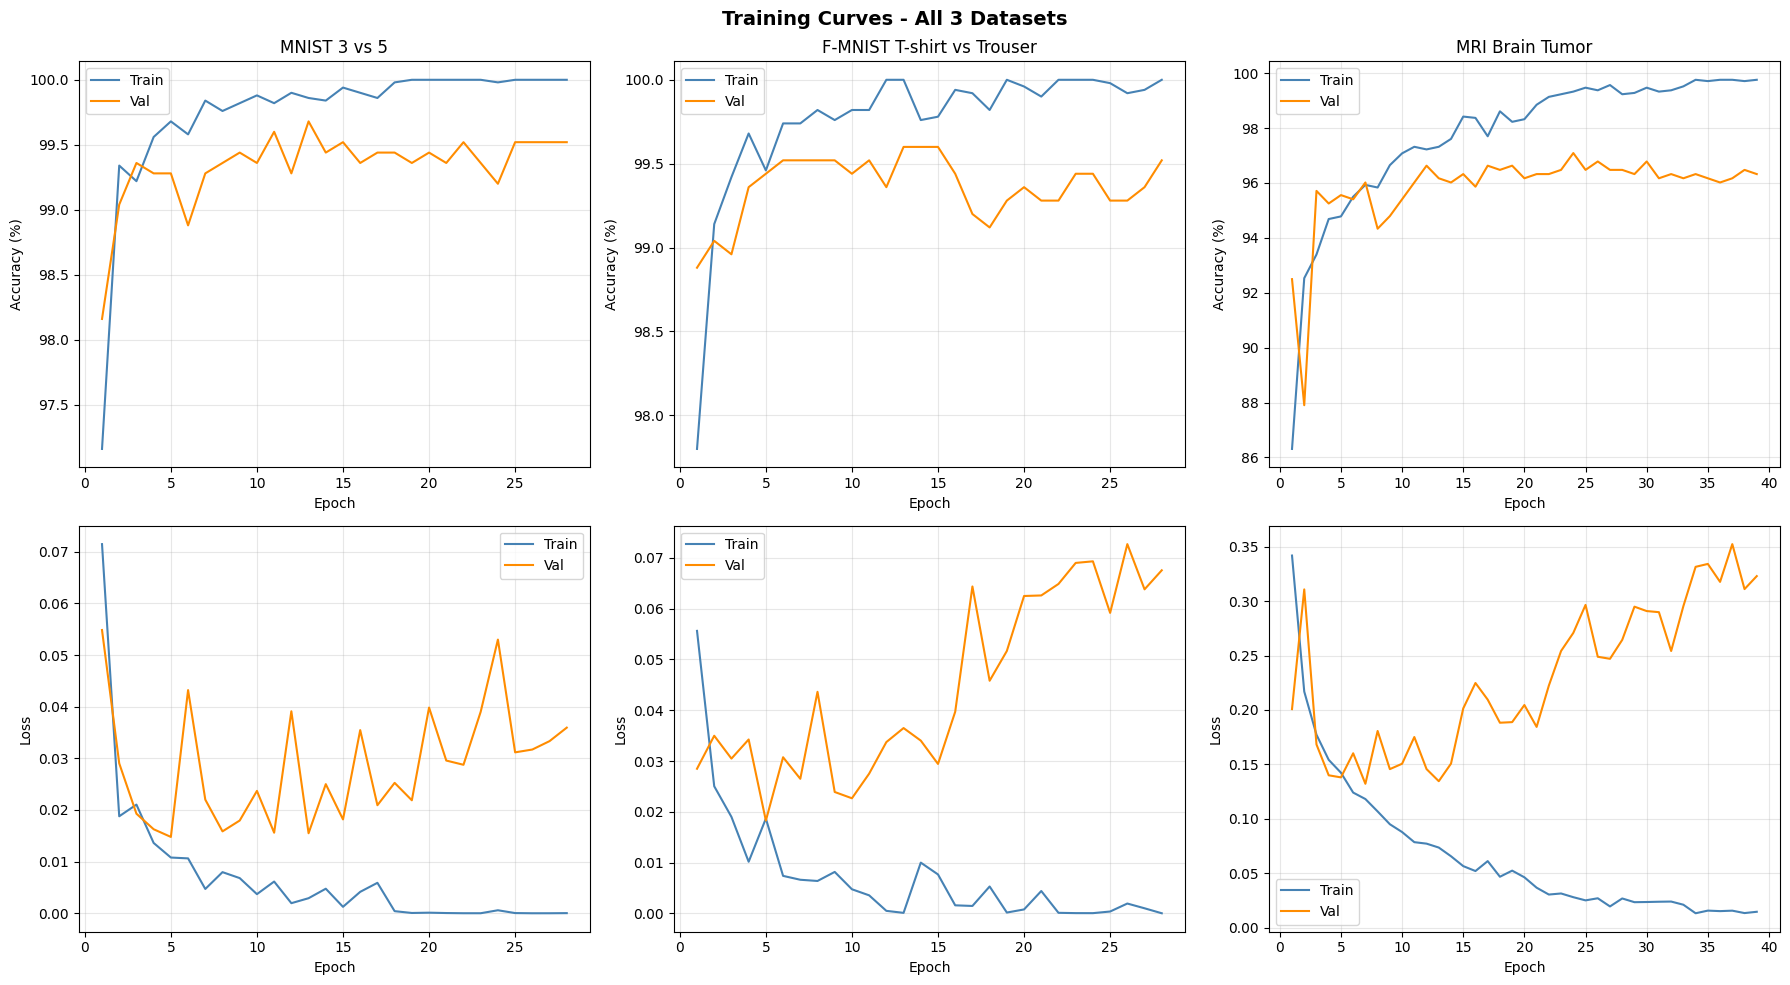

Saved training_curves.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training Curves - All 3 Datasets', fontsize=14, fontweight='bold')

all_histories = [
    (mnist_history,  'MNIST 3 vs 5'),
    (fmnist_history, 'F-MNIST T-shirt vs Trouser'),
    (mri_history,    'MRI Brain Tumor'),
]

for col, (hist, name) in enumerate(all_histories):
    ep = range(1, len(hist['train_acc']) + 1)

    # Accuracy
    axes[0, col].plot(ep, [v*100 for v in hist['train_acc']], label='Train', color='steelblue')
    axes[0, col].plot(ep, [v*100 for v in hist['val_acc']],   label='Val',   color='darkorange')
    axes[0, col].set_title(name)
    axes[0, col].set_ylabel('Accuracy (%)')
    axes[0, col].set_xlabel('Epoch')
    axes[0, col].legend()
    axes[0, col].grid(alpha=0.3)

    # Loss
    axes[1, col].plot(ep, hist['train_loss'], label='Train', color='steelblue')
    axes[1, col].plot(ep, hist['val_loss'],   label='Val',   color='darkorange')
    axes[1, col].set_ylabel('Loss')
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].legend()
    axes[1, col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()
print("Saved training_curves.png")

In [ ]:
def add_gaussian_noise(tensor, std=0.1):
    noise = torch.randn_like(tensor) * std
    return torch.clamp(tensor + noise, -1.0, 1.0)

@torch.no_grad()
def test_with_noise(model, loader, noise_fn, noise_params):
    results = []
    model.eval()
    for param in noise_params:
        correct, total = 0, 0
        for imgs, labels in loader:
            imgs_noisy = noise_fn(imgs, param).to(DEVICE)
            labels     = labels.float().unsqueeze(1).to(DEVICE)
            outputs    = model(imgs_noisy)
            preds      = (torch.sigmoid(outputs) >= 0.5).float()
            correct   += (preds == labels).sum().item()
            total     += imgs.size(0)
        results.append((param, 100.0 * correct / total))
    return results

print("Noise functions ready")

Noise functions ready


In [ ]:
gaussian_stds = [0.0, 0.05, 0.10]


datasets_to_test = {
    'MNIST'  : (mnist_model,  mnist_loaders['test']),
    'F-MNIST': (fmnist_model, fmnist_loaders['test']),
    'MRI'    : (mri_model,    mri_loaders['test']),
}

noise_results = {}

for ds_name, (model, loader) in datasets_to_test.items():
    print(f"\nTesting {ds_name}...")
    model.to(DEVICE)
    noise_results.setdefault('Gaussian',      {})[ds_name] = test_with_noise(model, loader, add_gaussian_noise,    gaussian_stds)
    print(f"Done")

print("\n All noise tests complete")


Testing MNIST...
Done

Testing F-MNIST...
Done

Testing MRI...
Done

 All noise tests complete


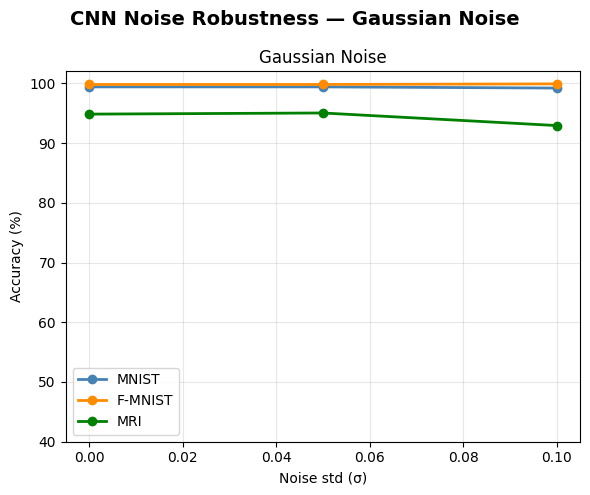

In [ ]:
colors = {
    'MNIST': 'steelblue',
    'F-MNIST': 'darkorange',
    'MRI': 'green'
}

x_labels = {
    'Gaussian': 'Noise std (σ)',
}

fig, ax = plt.subplots(figsize=(6, 5))

fig.suptitle(
    'CNN Noise Robustness — Gaussian Noise',
    fontsize=14,
    fontweight='bold'
)

noise_type = 'Gaussian'

for ds_name, results in noise_results[noise_type].items():

    params = [r[0] for r in results]
    accs   = [r[1] for r in results]

    ax.plot(
        params,
        accs,
        marker='o',
        linewidth=2,
        label=ds_name,
        color=colors[ds_name]
    )

ax.set_title('Gaussian Noise')

ax.set_xlabel(x_labels[noise_type])

ax.set_ylabel('Accuracy (%)')

ax.legend()

ax.grid(alpha=0.3)

ax.set_ylim(40, 102)

plt.tight_layout()

plt.savefig('noise_robustness.png', dpi=120)

plt.show()

In [ ]:
criterion = nn.BCEWithLogitsLoss()
results_clean = {}

for ds_name, (model, loader) in datasets_to_test.items():
    model.to(DEVICE)
    _, acc = evaluate(model, loader, criterion)
    results_clean[ds_name] = acc * 100

paper_cnn = {'MNIST': 98.79, 'F-MNIST': 99.19, 'MRI': 89.43}

print(f"\n{'='*55}")
print(f"  FINAL RESULTS vs PAPER (Table 1)")
print(f"{'='*55}")
print(f"{'Dataset':<12} {'Our CNN':>10} {'Paper CNN':>12} {'Diff':>8}")
print("-"*45)
for ds in ['MNIST', 'F-MNIST', 'MRI']:
    our   = results_clean[ds]
    paper = paper_cnn[ds]
    print(f"{ds:<12} {our:>9.2f}%  {paper:>10.2f}%  {our-paper:>+7.2f}%")
print("="*55)


  FINAL RESULTS vs PAPER (Table 1)
Dataset         Our CNN    Paper CNN     Diff
---------------------------------------------
MNIST            99.40%       98.79%    +0.61%
F-MNIST          99.80%       99.19%    +0.61%
MRI              94.84%       89.43%    +5.41%


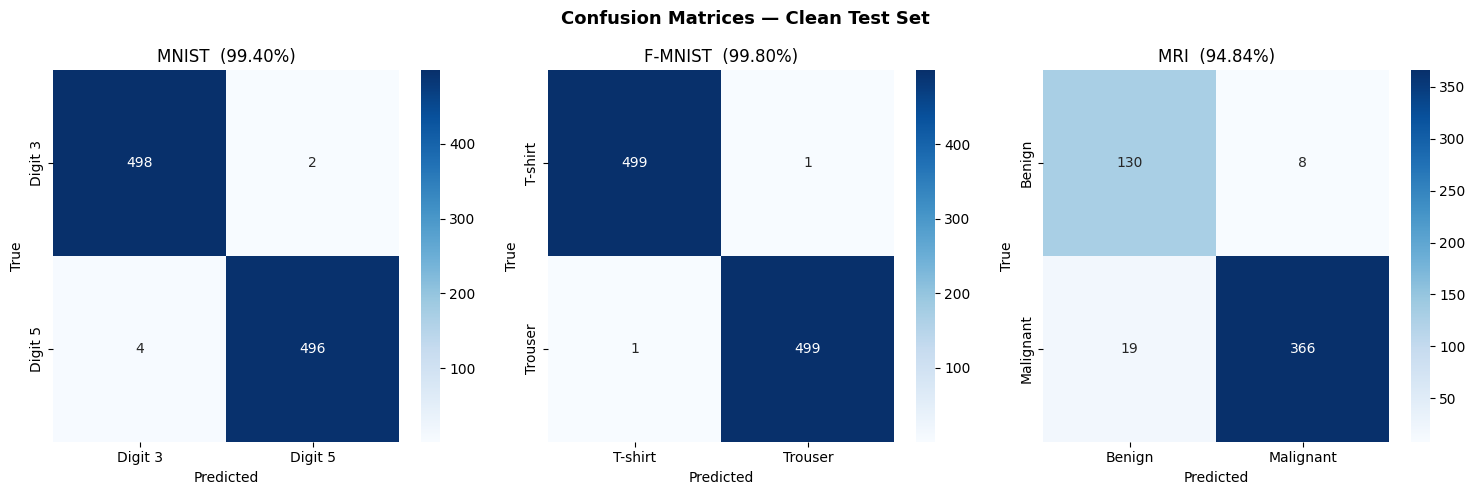

Saved confusion_matrices.png


In [ ]:
class_labels_map = {
    'MNIST'  : ['Digit 3',  'Digit 5'],
    'F-MNIST': ['T-shirt',  'Trouser'],
    'MRI'    : ['Benign',   'Malignant'],
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Confusion Matrices — Clean Test Set', fontsize=13, fontweight='bold')

for col, (ds_name, (model, loader)) in enumerate(datasets_to_test.items()):
    model.to(DEVICE).eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            outputs = model(imgs.to(DEVICE))
            preds   = (torch.sigmoid(outputs) >= 0.5).long().cpu().squeeze()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels_map[ds_name],
                yticklabels=class_labels_map[ds_name],
                ax=axes[col])
    axes[col].set_title(f'{ds_name}  ({results_clean[ds_name]:.2f}%)')
    axes[col].set_xlabel('Predicted')
    axes[col].set_ylabel('True')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120)
plt.show()
print("Saved confusion_matrices.png")

In [ ]:
for ds_name, (model, loader) in datasets_to_test.items():
    model.to(DEVICE).eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            outputs = model(imgs.to(DEVICE))
            preds   = (torch.sigmoid(outputs) >= 0.5).long().cpu().squeeze()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    print(f"\n{'='*45}")
    print(f"  {ds_name}")
    print('='*45)
    print(classification_report(all_labels, all_preds,
                                 target_names=class_labels_map[ds_name]))


  MNIST
              precision    recall  f1-score   support

     Digit 3       0.99      1.00      0.99       500
     Digit 5       1.00      0.99      0.99       500

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000


  F-MNIST
              precision    recall  f1-score   support

     T-shirt       1.00      1.00      1.00       500
     Trouser       1.00      1.00      1.00       500

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


  MRI
              precision    recall  f1-score   support

      Benign       0.87      0.94      0.91       138
   Malignant       0.98      0.95      0.96       385

    accuracy                           0.95       523
   macro avg       0.93      0.95      0.94       523
weighted avg       0.95      0.95      0.95    